In [33]:
fichiers='data\donnees_sanitoral.xlsx'

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\julie\AppData\Local\Temp\ipykernel_7136\431037939.py:1: SyntaxWarning: invalid escape sequence '\d'
  fichiers='data\donnees_sanitoral.xlsx'


In [34]:
# Import des librairies

import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

# Charger les DF des différents pages

DF : projects_plans, actual_duration, project_type, locations, country_profiles  
- Vérifier que les headers sont OK  
- afficher les types de données  
- afficher actual_duration, projects_plans


In [35]:
# Chargement des données
projects_plans = pd.read_excel(fichiers, sheet_name='Projects_plans', header=2)
actual_duration = pd.read_excel(fichiers, sheet_name='Actual_Duration', header=5)
project_type = pd.read_excel(fichiers, sheet_name='Project type', header=3)
locations = pd.read_excel(fichiers, sheet_name='Projects_Locations', header=1)
country_profiles = pd.read_excel(fichiers, sheet_name='Country_Profiles', header=1)

In [36]:
projects_plans.dtypes

Project ID                     int64
Phase                            str
Start Date            datetime64[us]
Planned_Duration               int64
Planned_Cost                   int64
Planned_Delivrable             int64
dtype: object

In [37]:
actual_duration

,Project,Phase,Actual_Duration
0,1,Phase 1 - Planning,196
1,1,Phase 2 - Initiation,7
2,1,Phase 3 - Implementation,176
3,1,Phase 4 - Manufacturing,64
4,2,Phase 1 - Planning,16
...,...,...,...
515,104,Phase 1 - Planning,163
516,104,Phase 2 - Initiation,179
517,104,Phase 3 - Implementation,168
518,104,Phase 4 - Manufacturing,140


# Jointures

Joindre projects_plans et actual_duration dans un df, par Project ID et Phase  
Attention : vérifier la jointure


In [38]:
# jointures
df_merge = pd.merge(projects_plans, actual_duration, 
              left_on=['Project ID', 'Phase'], 
              right_on=['Project', 'Phase'], 
              how='outer', 
              indicator = True)
df_merge

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Delivrable,Project,Actual_Duration,_merge
0,1,Phase 1 - Planning,2018-01-16,196,50000,10,1,196,both
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17,1,7,both
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26,1,176,both
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23,1,64,both
4,2,Phase 1 - Planning,2018-01-30,16,100000,6,2,16,both
...,...,...,...,...,...,...,...,...,...
515,103,Phase F - Post-deployment,2021-04-21,167,1400,24,103,171,both
516,104,Phase 1 - Planning,2018-05-12,186,50000,21,104,163,both
517,104,Phase 2 - Initiation,2018-06-07,185,100000,27,104,179,both
518,104,Phase 3 - Implementation,2018-06-23,72,150000,17,104,168,both


In [39]:
df_merge.value_counts()

Project ID  Phase                     Start Date  Planned_Duration  Planned_Cost  Planned_Delivrable  Project  Actual_Duration  _merge    
1           Phase 1 - Planning        2018-01-16  196               50000         10                  1        196              both          1
            Phase 2 - Initiation      2018-01-31  15                100000        17                  1        7                both          1
            Phase 3 - Implementation  2018-04-17  197               150000        26                  1        176              both          1
            Phase 4 - Manufacturing   2018-10-10  61                450000        23                  1        64               both          1
2           Phase 1 - Planning        2018-01-30  16                100000        6                   2        16               both          1
                                                                                                                                             

# Calculs

Ajouter dans le DF :  
- le retard (j) : Delay = Actual_Duration - Planned_Duration
- Is_Late : 1 = retard, 0 = pas de retard
- Start_Month, Start_Quarter, Start_Year

In [40]:
# Calcul du retard (en jours)
df_merge['Delay'] = df_merge['Actual_Duration'] - df_merge['Planned_Duration']
df_merge['Is_Late'] = (df_merge['Delay'] > 0).astype(int)  # Variable binaire : 1 = retard, 0 = pas de retard

# Degré de retard (catégories)
df_merge['Delay_Category'] = pd.cut(df_merge['Delay'], 
                               bins=[-float('inf'), -1, 0, 30, 90, float('inf')],
                               labels=['En avance', 'À l\'heure', 'Petit retard (<1mois)', 
                                      'Retard moyen (1-3mois)', 'Grand retard (>3mois)'])
df_merge

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Delivrable,Project,Actual_Duration,_merge,Delay,Is_Late,Delay_Category
0,1,Phase 1 - Planning,2018-01-16,196,50000,10,1,196,both,0,0,À l'heure
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17,1,7,both,-8,0,En avance
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26,1,176,both,-21,0,En avance
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23,1,64,both,3,1,Petit retard (<1mois)
4,2,Phase 1 - Planning,2018-01-30,16,100000,6,2,16,both,0,0,À l'heure
...,...,...,...,...,...,...,...,...,...,...,...,...
515,103,Phase F - Post-deployment,2021-04-21,167,1400,24,103,171,both,4,1,Petit retard (<1mois)
516,104,Phase 1 - Planning,2018-05-12,186,50000,21,104,163,both,-23,0,En avance
517,104,Phase 2 - Initiation,2018-06-07,185,100000,27,104,179,both,-6,0,En avance
518,104,Phase 3 - Implementation,2018-06-23,72,150000,17,104,168,both,96,1,Grand retard (>3mois)


In [41]:
# Mois de début (saisonnalité)
df_merge['Start_Month'] = pd.to_datetime(df_merge['Start Date']).dt.month
df_merge['Start_Quarter'] = pd.to_datetime(df_merge['Start Date']).dt.quarter
df_merge['Start_Year'] = pd.to_datetime(df_merge['Start Date']).dt.year

# Charge de travail initiale
df_merge['Planned_Intensity'] = df_merge['Planned_Delivrable'] / df_merge['Planned_Duration'] * 30  # livrables/mois
df_merge

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Delivrable,Project,Actual_Duration,_merge,Delay,Is_Late,Delay_Category,Start_Month,Start_Quarter,Start_Year,Planned_Intensity
0,1,Phase 1 - Planning,2018-01-16,196,50000,10,1,196,both,0,0,À l'heure,1,1,2018,1.530612
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17,1,7,both,-8,0,En avance,1,1,2018,34.000000
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26,1,176,both,-21,0,En avance,4,2,2018,3.959391
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23,1,64,both,3,1,Petit retard (<1mois),10,4,2018,11.311475
4,2,Phase 1 - Planning,2018-01-30,16,100000,6,2,16,both,0,0,À l'heure,1,1,2018,11.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,103,Phase F - Post-deployment,2021-04-21,167,1400,24,103,171,both,4,1,Petit retard (<1mois),4,2,2021,4.311377
516,104,Phase 1 - Planning,2018-05-12,186,50000,21,104,163,both,-23,0,En avance,5,2,2018,3.387097
517,104,Phase 2 - Initiation,2018-06-07,185,100000,27,104,179,both,-6,0,En avance,6,2,2018,4.378378
518,104,Phase 3 - Implementation,2018-06-23,72,150000,17,104,168,both,96,1,Grand retard (>3mois),6,2,2018,7.083333


# Aggrégations

Récupérer par projet (Project ID) :  
- somme Planned_Duration  
- somme Planned_Cost
- somme Planned_Delivrable
- nombre de Phase
- somme Delay
- max Is_Late
- Start_Month
- Start_Year



In [42]:
#df_proj = df.groupby()...
project_features = df_merge.groupby('Project ID').agg({
    'Planned_Duration': 'sum',
    'Planned_Cost': 'sum',
    'Planned_Delivrable': 'sum',
    'Phase': 'count',
    'Delay': 'sum',
    'Is_Late': 'max',
    'Start_Month': 'first',
    'Start_Year': 'first'
}).rename(columns={
    'Planned_Duration': 'Total_Planned_Duration',
    'Planned_Cost': 'Total_Planned_Cost',
    'Planned_Delivrable': 'Total_Planned_Delivrables',
    'Phase': 'Nb_Phases',
    'Delay': 'Total_Delay',
    'Is_Late': 'Project_Had_Late_Phase'
})

project_features

,Total_Planned_Duration,Total_Planned_Cost,Total_Planned_Delivrables,Nb_Phases,Total_Delay,Project_Had_Late_Phase,Start_Month,Start_Year
Project ID,,,,,,,,
1,469,750000,76,4,-26,1,1,2018
2,365,1500000,71,4,-62,1,1,2018
3,398,750000,73,4,65,1,3,2018
4,151,750000,95,4,143,1,4,2018
5,435,750000,59,4,-139,1,1,2018
...,...,...,...,...,...,...,...,...
100,606,91200,95,6,9,1,5,2020
101,539,121200,96,6,-43,1,1,2020
102,612,85200,70,6,-174,1,3,2020


In [43]:
# Fusion avec le type de projet
df_merge = pd.merge(df_merge, project_type, on='Project ID', how='left')

# Fusion avec la localisation
df_merge = pd.merge(df_merge, locations, on='Project ID', how='left')
df_merge = pd.merge(df_merge, country_profiles, on='Country', how='left')

df_merge

,Project ID,Phase,Start Date,Planned_Duration,Planned_Cost,Planned_Delivrable,Project,Actual_Duration,_merge,Delay,Is_Late,Delay_Category,Start_Month,Start_Quarter,Start_Year,Planned_Intensity,Project Type,Country,Region,Type
0,1,Phase 1 - Planning,2018-01-16,196,50000,10,1,196,both,0,0,À l'heure,1,1,2018,1.530612,Marketing - Launch of new product,Equateur,North and Latin America,Affiliate
1,1,Phase 2 - Initiation,2018-01-31,15,100000,17,1,7,both,-8,0,En avance,1,1,2018,34.000000,Marketing - Launch of new product,Equateur,North and Latin America,Affiliate
2,1,Phase 3 - Implementation,2018-04-17,197,150000,26,1,176,both,-21,0,En avance,4,2,2018,3.959391,Marketing - Launch of new product,Equateur,North and Latin America,Affiliate
3,1,Phase 4 - Manufacturing,2018-10-10,61,450000,23,1,64,both,3,1,Petit retard (<1mois),10,4,2018,11.311475,Marketing - Launch of new product,Equateur,North and Latin America,Affiliate
4,2,Phase 1 - Planning,2018-01-30,16,100000,6,2,16,both,0,0,À l'heure,1,1,2018,11.250000,Marketing - Launch of new product,France,Western Europe,Affiliate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,103,Phase F - Post-deployment,2021-04-21,167,1400,24,103,171,both,4,1,Petit retard (<1mois),4,2,2021,4.311377,IT - CRM Implementation,La Reunion,Central/Eastern Europe-Middle East-Africa,Affiliate
516,104,Phase 1 - Planning,2018-05-12,186,50000,21,104,163,both,-23,0,En avance,5,2,2018,3.387097,Marketing - Launch of new product,Bielorussie,Central/Eastern Europe-Middle East-Africa,Distributor
517,104,Phase 2 - Initiation,2018-06-07,185,100000,27,104,179,both,-6,0,En avance,6,2,2018,4.378378,Marketing - Launch of new product,Bielorussie,Central/Eastern Europe-Middle East-Africa,Distributor
518,104,Phase 3 - Implementation,2018-06-23,72,150000,17,104,168,both,96,1,Grand retard (>3mois),6,2,2018,7.083333,Marketing - Launch of new product,Bielorussie,Central/Eastern Europe-Middle East-Africa,Distributor


In [44]:
(projects_plans['Planned_Duration']>190).value_counts()

Planned_Duration
False    491
True      29
Name: count, dtype: int64

# Graphique histogram

Histogramme des Planned_Duration

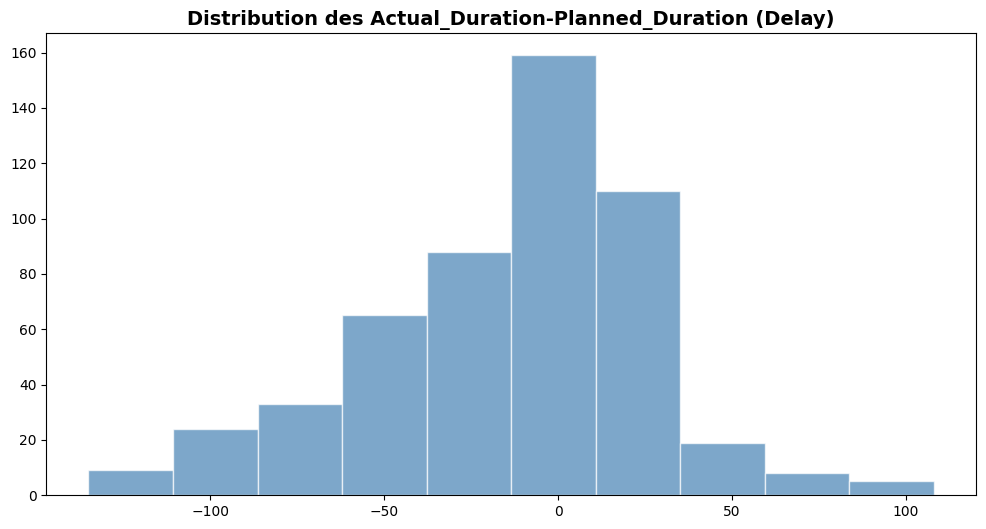

In [53]:
# Figure 1: Histogramme de base
plt.figure(figsize=(12, 6))

plt.hist(df_merge['Delay'], 
         #bins=30, 
         color='steelblue', 
         edgecolor='white',
         alpha=0.7)

plt.title('Distribution des Actual_Duration-Planned_Duration (Delay)', fontsize=14, fontweight='bold')

plt.show()


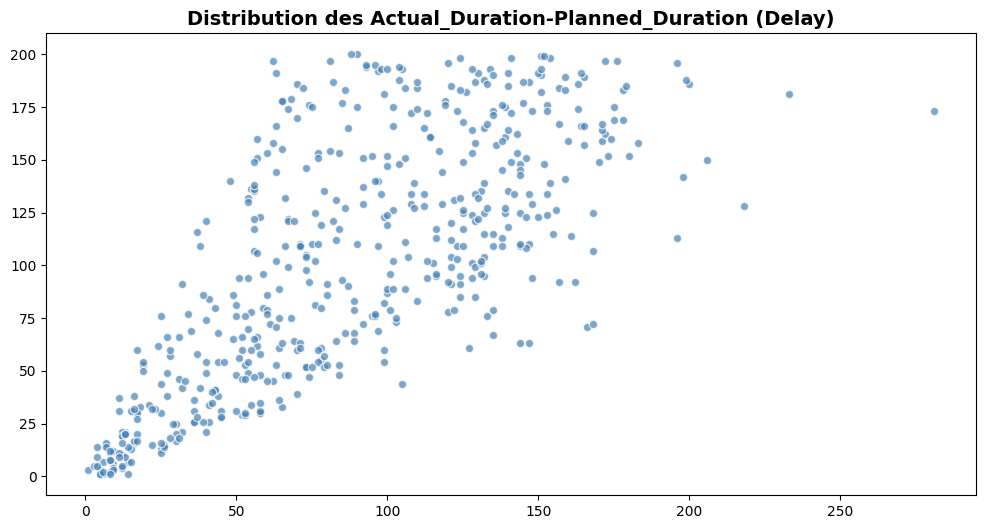

In [56]:
# Nuage de points
plt.figure(figsize=(12, 6))

plt.scatter(df_merge['Actual_Duration'],df_merge['Planned_Duration'], 
         color='steelblue', 
         edgecolor='white',
         alpha=0.7)

plt.title('Distribution des Actual_Duration-Planned_Duration (Delay)', fontsize=14, fontweight='bold')

plt.show()